# 🩺 CheXpert Classification with Uncertainty Handling (U-Zeros)

## 📌 Objective
This notebook implements the **U-Zeros uncertainty handling strategy** for multi-label thoracic disease classification using the CheXpert dataset.

In this approach, all uncertain labels (-1) are treated as **negative (0)** during training.

---

## 📊 Dataset
- Dataset: CheXpert (Stanford)
- Total Samples: ~220K chest X-rays
- Task: Multi-label classification (13 diseases)
- Labels:
  - `1` → Positive
  - `0` → Negative
  - `-1` → Uncertain (treated as **0 in U-Zeros**)

---

## ⚙️ Workflow Overview
1. Load dataset and inspect structure
2. Clean the Dataset 
3. Handle uncertainty using U-Zeros strategy  
4. Preprocess images and labels  
5. Train deep learning models : ResNet-50, DenseNet-121, CamChex, Multiview
6. Evaluate using classification metrics  
7. Analyze results  

---

## 📦 Libraries Used
- PyTorch (Deep Learning)
- torchvision (Pretrained models & transforms)
- pandas / numpy (Data handling)
- sklearn (Evaluation metrics)
- matplotlib (Visualization)

## Import all the required libraries

In [1]:
# Import all the libraries here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import boto3
import os
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from PIL import Image

In [1]:
# Read the dataset
train_df = pd.read_csv("train_cheXbert.csv")

In [3]:
# Look at the shape of the dataset
print("Shape of dataset:", train_df.shape)
print("\nFirst 5 rows:")
print(train_df.head())

Shape of dataset: (223414, 19)

First 5 rows:
                                                Path     Sex  Age  \
0  CheXpert-v1.0/train/patient00001/study1/view1_...  Female   68   
1  CheXpert-v1.0/train/patient00002/study2/view1_...  Female   87   
2  CheXpert-v1.0/train/patient00002/study1/view1_...  Female   83   
3  CheXpert-v1.0/train/patient00002/study1/view2_...  Female   83   
4  CheXpert-v1.0/train/patient00003/study1/view1_...    Male   41   

  Frontal/Lateral AP/PA  Enlarged Cardiomediastinum  Cardiomegaly  \
0         Frontal    AP                         NaN           NaN   
1         Frontal    AP                         NaN           1.0   
2         Frontal    AP                         NaN           NaN   
3         Lateral   NaN                         NaN           NaN   
4         Frontal    AP                         NaN           NaN   

   Lung Opacity  Lung Lesion  Edema  Consolidation  Pneumonia  Atelectasis  \
0           NaN          NaN    NaN           

In [4]:
# Look at the description of the dataset
train_df[['Sex', 'Age']].info()
print("Unique Sex values:", train_df['Sex'].unique()) #Checking Gender Types
print(train_df['Age'].describe()) # Basic stats for Age

<class 'pandas.DataFrame'>
RangeIndex: 223414 entries, 0 to 223413
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   Sex     223414 non-null  str  
 1   Age     223414 non-null  int64
dtypes: int64(1), str(1)
memory usage: 3.4 MB
Unique Sex values: <StringArray>
['Female', 'Male', 'Unknown']
Length: 3, dtype: str
count    223414.000000
mean         60.527662
std          17.995927
min           0.000000
25%          49.000000
50%          62.000000
75%          74.000000
max         110.000000
Name: Age, dtype: float64


## Data Cleaning

#### 1. Clean the dataset using AGE variable

In [5]:
# Number of patients between age 0 and 17
age_0_17_count = train_df[(train_df['Age'] >= 0) & (train_df['Age'] <= 17)].shape[0]
print("Number of patients between age 0-17 years:", age_0_17_count)

train_df = train_df[train_df['Age'] > 17] # remove them

print("New dataset shape after removing 0-17 age group:", train_df.shape)

Number of patients between age 0-17 years: 3
New dataset shape after removing 0-17 age group: (223411, 19)


#### 2. Clean the dataset using GENDER variable

In [6]:
# Count number of "Unknown" in Sex column
unknown_count = (train_df['Sex'] == 'Unknown').sum()
print("Number of 'Unknown' Sex values:", unknown_count)

train_df = train_df[train_df['Sex'] != 'Unknown'] #remove them

print("Updated dataset shape:", train_df.shape)

Number of 'Unknown' Sex values: 1
Updated dataset shape: (223410, 19)


In [7]:
# Extract patient ID from Path column
train_df['Patient_ID'] = train_df['Path'].str.extract(r'(patient\d+)')
print(train_df[['Path', 'Patient_ID']].head())

                                                Path    Patient_ID
0  CheXpert-v1.0/train/patient00001/study1/view1_...  patient00001
1  CheXpert-v1.0/train/patient00002/study2/view1_...  patient00002
2  CheXpert-v1.0/train/patient00002/study1/view1_...  patient00002
3  CheXpert-v1.0/train/patient00002/study1/view2_...  patient00002
4  CheXpert-v1.0/train/patient00003/study1/view1_...  patient00003


#### 3. Remove the variable "Support Devices"

In [8]:
train_df = train_df.drop(columns=["Support Devices"])
print(train_df.head())

                                                Path     Sex  Age  \
0  CheXpert-v1.0/train/patient00001/study1/view1_...  Female   68   
1  CheXpert-v1.0/train/patient00002/study2/view1_...  Female   87   
2  CheXpert-v1.0/train/patient00002/study1/view1_...  Female   83   
3  CheXpert-v1.0/train/patient00002/study1/view2_...  Female   83   
4  CheXpert-v1.0/train/patient00003/study1/view1_...    Male   41   

  Frontal/Lateral AP/PA  Enlarged Cardiomediastinum  Cardiomegaly  \
0         Frontal    AP                         NaN           NaN   
1         Frontal    AP                         NaN           1.0   
2         Frontal    AP                         NaN           NaN   
3         Lateral   NaN                         NaN           NaN   
4         Frontal    AP                         NaN           NaN   

   Lung Opacity  Lung Lesion  Edema  Consolidation  Pneumonia  Atelectasis  \
0           NaN          NaN    NaN            NaN        NaN          NaN   
1           1.

#### 4. Clean the dataset with patients with more than 10 images

In [9]:
# Count number of images per patient
images_per_patient = train_df['Patient_ID'].value_counts()

# Patients with more than 10 images
patients_more_than_10 = images_per_patient[images_per_patient > 50]

print("Number of patients with more than 10 images:", len(patients_more_than_10))
print("\nTop patients with many images:")
print(patients_more_than_10.head())

Number of patients with more than 10 images: 63

Top patients with many images:
Patient_ID
patient28746    92
patient33155    92
patient04462    89
patient24163    86
patient34615    85
Name: count, dtype: int64


* NOTE:
  - Patients with more than 10 images - 3522
  - Patients with more than 20 images - 857

In [10]:
# patients with >50 images
patients_more_than_50 = images_per_patient[images_per_patient > 50].index

# rows that belong to these patients
rows_to_remove = train_df[train_df['Patient_ID'].isin(patients_more_than_50)]

print("Images that will be removed:", rows_to_remove.shape[0])

total_images = train_df.shape[0]
images_removed = rows_to_remove.shape[0]
percent_removed = (images_removed / total_images) * 100
print(f"Percent of training data removed: {percent_removed:.2f}%")

Images that will be removed: 4032
Percent of training data removed: 1.80%


In [11]:
train_df = train_df[~train_df['Patient_ID'].isin(patients_more_than_50)]
print("Shape after removing patients with >50 images:", train_df.shape)

Shape after removing patients with >50 images: (219378, 19)


## Handling Uncertainty

In [12]:
# Define thoracic findings columns
disease_cols = [
    'No Finding',
    'Enlarged Cardiomediastinum',
    'Cardiomegaly',
    'Lung Opacity',
    'Lung Lesion',
    'Edema',
    'Consolidation',
    'Pneumonia',
    'Atelectasis',
    'Pneumothorax',
    'Pleural Effusion',
    'Pleural Other',
    'Fracture']

pathology_cols = [col for col in disease_cols if col != 'No Finding'] # Define disease columns
base_df = train_df.copy() # Create a base column
base_df[disease_cols] = base_df[disease_cols].fillna(0) # Fill missing labels with 0

### U Ones

In [13]:
u_zeros_df = base_df.copy()
u_zeros_df[pathology_cols] = u_zeros_df[pathology_cols].replace(-1, 0)
print("\nU-Zeros unique values:")
for col in disease_cols:
    print(f"{col}: {sorted(pd.Series(u_zeros_df[col].dropna().unique()).tolist())}")
model_df = u_zeros_df.copy()


U-Zeros unique values:
No Finding: [0.0, 1.0]
Enlarged Cardiomediastinum: [0.0, 1.0]
Cardiomegaly: [0.0, 1.0]
Lung Opacity: [0.0, 1.0]
Lung Lesion: [0.0, 1.0]
Edema: [0.0, 1.0]
Consolidation: [0.0, 1.0]
Pneumonia: [0.0, 1.0]
Atelectasis: [0.0, 1.0]
Pneumothorax: [0.0, 1.0]
Pleural Effusion: [0.0, 1.0]
Pleural Other: [0.0, 1.0]
Fracture: [0.0, 1.0]


### Filter only frontal images

In [50]:
# model_df = u_zeros_df[u_zeros_df["Frontal/Lateral"] == "Frontal"].copy()

print("Frontal-only shape:", model_df.shape)
print(model_df["Frontal/Lateral"].value_counts())
print("Unique patients:", model_df["Patient_ID"].nunique())

Frontal-only shape: (219378, 19)
Frontal/Lateral
Frontal    187337
Lateral     32041
Name: count, dtype: int64
Unique patients: 64473


### Splitting the dataset

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
# unique patient IDs
patient_ids = model_df["Patient_ID"].unique()

# split patients
train_patients, val_patients = train_test_split(
    patient_ids,
    test_size=0.2,
    random_state=42
)

# create patient-wise splits
train_split_df = model_df[model_df["Patient_ID"].isin(train_patients)].copy()
val_split_df = model_df[model_df["Patient_ID"].isin(val_patients)].copy()

print("Train split shape:", train_split_df.shape)
print("Val split shape:", val_split_df.shape)

print("Train patients:", train_split_df["Patient_ID"].nunique())
print("Val patients:", val_split_df["Patient_ID"].nunique())

Train split shape: (175985, 19)
Val split shape: (43393, 19)
Train patients: 51578
Val patients: 12895


In [16]:
# Just for verification split is accurate
train_patient_set = set(train_split_df["Patient_ID"].unique())
val_patient_set = set(val_split_df["Patient_ID"].unique())

overlap = train_patient_set.intersection(val_patient_set)
print("Number of overlapping patients:", len(overlap))

Number of overlapping patients: 0


## Image Preprocessing

In [20]:
import torch
from torchvision import transforms
from torch.utils.data import Dataset, BatchSampler
from PIL import Image
from torch.utils.data import DataLoader

In [21]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((320, 320)),      
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((320, 320)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [22]:
class CheXpertDataset(Dataset):
    def __init__(self, df, label_cols, transform=None):
        self.df = df.reset_index(drop=True)
        self.label_cols = label_cols
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        frontal_path = resolve_path(self.df.loc[idx, "Path_frontal"])
        lateral_path = resolve_path(self.df.loc[idx, "Path_lateral"])

        try:
            frontal_img = Image.open(frontal_path).convert("RGB")
        except (FileNotFoundError, OSError, TypeError):
            frontal_img = Image.new("RGB", (320, 320), 0)

        try:
            lateral_img = Image.open(lateral_path).convert("RGB")
        except (FileNotFoundError, OSError, TypeError):
            lateral_img = Image.new("RGB", (320, 320), 0)

        if self.transform:
            frontal_img = self.transform(frontal_img)
            lateral_img = self.transform(lateral_img)

        labels = self.df.loc[idx, self.label_cols].values.astype(np.float32)
        return frontal_img, lateral_img, torch.tensor(labels, dtype=torch.float32)



class MultilabelBalancedBatchSampler(BatchSampler):
    """
    Builds batches with:
    - half positive studies (at least one disease present)
    - half negative studies (all disease labels are 0)

    Inside the positive pool, rarer-class samples are favored using
    a rarity score based on inverse class frequency.
    """
    def __init__(self, labels_df, batch_size, pos_fraction=0.5):
        self.labels = labels_df.values.astype(np.float32)
        self.batch_size = batch_size
        self.pos_fraction = pos_fraction

        self.num_pos = max(1, int(batch_size * pos_fraction))
        self.num_neg = batch_size - self.num_pos

        # Positive if any disease is present
        self.positive_mask = (self.labels.sum(axis=1) > 0)
        self.negative_mask = ~self.positive_mask

        self.positive_indices = np.where(self.positive_mask)[0]
        self.negative_indices = np.where(self.negative_mask)[0]

        if len(self.positive_indices) == 0:
            raise ValueError("No positive samples found for balanced batch sampling.")
        if len(self.negative_indices) == 0:
            raise ValueError("No negative samples found for balanced batch sampling.")

        # Class prevalence among training samples
        class_counts = self.labels.sum(axis=0)
        class_inv_freq = 1.0 / (class_counts + 1e-6)

        # Score each positive sample by how many rare classes it contains
        sample_scores = (self.labels * class_inv_freq).sum(axis=1)

        # Keep only positive pool scores
        pos_scores = sample_scores[self.positive_indices]

        # Normalize to a probability distribution
        pos_scores = np.clip(pos_scores, a_min=1e-8, a_max=None)
        self.pos_prob = pos_scores / pos_scores.sum()

        # Negatives sampled uniformly
        self.neg_prob = None

        # Number of batches per epoch
        self.n_batches = len(labels_df) // batch_size

    def __iter__(self):
        for _ in range(self.n_batches):
            pos_batch = np.random.choice(
                self.positive_indices,
                size=self.num_pos,
                replace=True,
                p=self.pos_prob
            )

            neg_batch = np.random.choice(
                self.negative_indices,
                size=self.num_neg,
                replace=True
            )

            batch = np.concatenate([pos_batch, neg_batch])
            np.random.shuffle(batch)

            yield batch.tolist()

    def __len__(self):
        return self.n_batches

In [23]:
import os

BASE = "/home/ubuntu/chexpert/chexpertchestxrays-u20210408"

BATCH_DIRS = [
    f"{BASE}/CheXpert-v1.0 batch 2 (train 1)",
    f"{BASE}/CheXpert-v1.0 batch 3 (train 2)",
    f"{BASE}/CheXpert-v1.0 batch 4 (train 3)",
]

def resolve_path(csv_path):
    # CSV path looks like: CheXpert-v1.0/train/patient00001/study1/view1_frontal.jpg
    relative = csv_path.replace("CheXpert-v1.0/train/", "")
    for batch_dir in BATCH_DIRS:
        candidate = os.path.join(batch_dir, relative)
        if os.path.exists(candidate):
            return candidate
    return None


In [24]:
train_dataset = CheXpertDataset(
    df=train_split_df,
    label_cols=disease_cols,
    transform=train_transform
)

val_dataset = CheXpertDataset(
    df=val_split_df,
    label_cols=disease_cols,
    transform=val_transform
)

balanced_batch_sampler = MultilabelBalancedBatchSampler(
    labels_df=train_split_df[disease_cols],
    batch_size=16,
    pos_fraction=0.5
)

train_loader = DataLoader(
    train_dataset,
    batch_sampler=balanced_batch_sampler,  # use sampler instead of batch_size+shuffle
    num_workers=8,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=8,
    pin_memory=True,
    persistent_workers=True
)

In [25]:
# Sanity check
frontal, lateral, labels = next(iter(train_loader))
print(f"Frontal: {frontal.shape}")
print(f"Lateral: {lateral.shape}")
print(f"Labels:  {labels.shape}")
print("Ready!")

Frontal: torch.Size([16, 3, 320, 320])
Lateral: torch.Size([16, 3, 320, 320])
Labels:  torch.Size([16, 13])
Ready!


## Model 1: ResNet 50

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from tqdm import tqdm

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [26]:
num_classes = len(disease_cols)   # should be 13

resnet50 = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# replace final fully connected layer
in_features = resnet50.fc.in_features
resnet50.fc = nn.Linear(in_features, num_classes)

resnet50 = resnet50.to(device)

print(resnet50)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [27]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(resnet50.parameters(), lr=1e-4)

In [28]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for images, labels in progress_bar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        progress_bar.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss

In [29]:
def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    all_labels = []
    all_probs = []

    with torch.no_grad():
        progress_bar = tqdm(loader, desc="Validation", leave=False)

        for images, labels in progress_bar:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.sigmoid(outputs)

            running_loss += loss.item() * images.size(0)

            all_labels.append(labels.cpu())
            all_probs.append(probs.cpu())

    epoch_loss = running_loss / len(loader.dataset)

    all_labels = torch.cat(all_labels, dim=0)
    all_probs = torch.cat(all_probs, dim=0)

    return epoch_loss, all_labels, all_probs

In [30]:
num_epochs = 3
best_val_loss = float("inf")
best_model_path = "best_resnet50_uzeros.pth"

for epoch in tqdm(range(num_epochs), desc="Epochs"):

    train_loss = train_epoch(resnet50, train_loader, criterion, optimizer, device)

    val_loss, val_labels, val_probs = validate_epoch(
        resnet50, val_loader, criterion, device
    )

    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    print("-" * 30)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(resnet50.state_dict(), best_model_path)
        print(f"Best model saved to {best_model_path}")

Training: 100%|██████████| 1176/1176 [21:25<00:00,  1.35it/s, loss=0.241]
                                                                         
Validation: 100%|██████████| 287/287 [10:41<00:00,  1.58it/s]
                                                             


Epoch [1/3]
Train Loss: 0.2360
Val Loss:   0.2971
------------------------------


Epochs:  33%|███▎      | 1/3 [32:07<1:04:15, 1927.50s/it]

Best model saved to best_resnet50_uzeros.pth



Training: 100%|██████████| 1176/1176 [20:12<00:00,  1.42it/s, loss=0.218]
                                                                         
Validation: 100%|██████████| 287/287 [10:40<00:00,  1.72it/s]
                                                             


Epoch [2/3]
Train Loss: 0.2137
Val Loss:   0.2891
------------------------------


Epochs:  67%|██████▋   | 2/3 [1:03:01<31:23, 1883.99s/it]

Best model saved to best_resnet50_uzeros.pth



Training: 100%|██████████| 1176/1176 [20:08<00:00,  1.44it/s, loss=0.202]
                                                                         
Epochs: 100%|██████████| 3/3 [1:33:49<00:00, 1876.58s/it]    


Epoch [3/3]
Train Loss: 0.2029
Val Loss:   0.2906
------------------------------


In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np

# Load best model before evaluation
resnet50.load_state_dict(torch.load(best_model_path, map_location=device))
resnet50 = resnet50.to(device)

val_loss, val_labels, val_probs = validate_epoch(
    resnet50, val_loader, criterion, device
)

# Convert tensors to numpy if needed
if isinstance(val_probs, torch.Tensor):
    val_probs = val_probs.cpu().numpy()

if isinstance(val_labels, torch.Tensor):
    val_labels = val_labels.cpu().numpy()

val_preds = (val_probs >= 0.5).astype(int)

label_cols = [
    'No Finding',
    'Enlarged Cardiomediastinum',
    'Cardiomegaly',
    'Lung Opacity',
    'Lung Lesion',
    'Edema',
    'Consolidation',
    'Pneumonia',
    'Atelectasis',
    'Pneumothorax',
    'Pleural Effusion',
    'Pleural Other',
    'Fracture'
]

results = []
aurocs = []

for i, disease in enumerate(label_cols):

    y_true = val_labels[:, i]
    y_pred = val_preds[:, i]
    y_prob = val_probs[:, i]

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    try:
        auroc = roc_auc_score(y_true, y_prob)
        aurocs.append(auroc)
    except:
        auroc = np.nan

    results.append({
        "Disease": disease,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "AUROC": auroc
    })

metrics_df = pd.DataFrame(results)

macro_auroc = np.nanmean(aurocs)

try:
    micro_auroc = roc_auc_score(val_labels.flatten(), val_probs.flatten())
except:
    micro_auroc = np.nan

print("\n=========================")
print(f"Overall Macro AUROC : {macro_auroc:.4f}")
print(f"Overall Micro AUROC : {micro_auroc:.4f}")
print("=========================\n")

metrics_df



Overall Macro AUROC : 0.7549
Overall Micro AUROC : 0.8548



,Disease,Accuracy,Precision,Recall,F1 Score,AUROC
0,No Finding,0.911432,0.000000,0.000000,0.000000,0.861485
1,Enlarged Cardiomediastinum,0.963380,0.347826,0.012021,0.023239,0.692559
2,Cardiomegaly,0.879196,0.662451,0.172855,0.274170,0.831664
3,Lung Opacity,0.615780,0.686315,0.374104,0.484248,0.721434
4,Lung Lesion,0.962536,0.535714,0.021739,0.041783,0.689882
5,Edema,0.782570,0.627778,0.372184,0.467316,0.805032
6,Consolidation,0.938904,0.456522,0.009375,0.018373,0.729752
7,Pneumonia,0.979253,0.279070,0.051064,0.086331,0.767457
8,Atelectasis,0.841733,0.500000,0.000860,0.001717,0.626897
9,Pneumothorax,0.918511,0.499245,0.220996,0.306373,0.813714


ECE: 0.0173


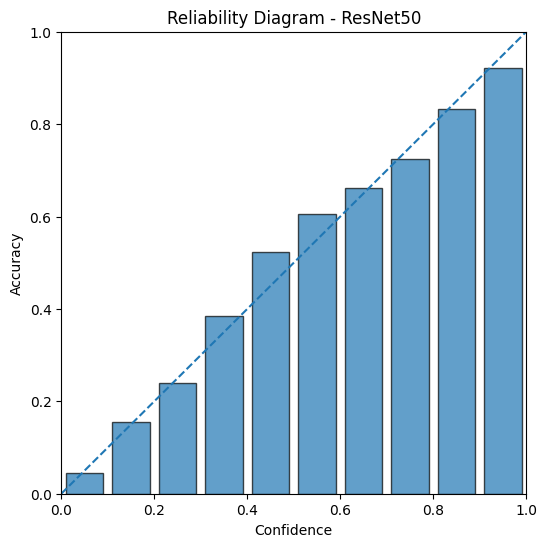

In [32]:
import numpy as np
import matplotlib.pyplot as plt

def compute_ece(y_true, y_prob, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1

    ece = 0.0
    bin_accs = []
    bin_confs = []
    bin_counts = []

    for b in range(n_bins):
        mask = bin_ids == b
        if np.sum(mask) > 0:
            acc = np.mean(y_true[mask])
            conf = np.mean(y_prob[mask])
            frac = np.mean(mask)

            ece += np.abs(acc - conf) * frac
            bin_accs.append(acc)
            bin_confs.append(conf)
            bin_counts.append(np.sum(mask))
        else:
            bin_accs.append(0.0)
            bin_confs.append(0.0)
            bin_counts.append(0)

    return ece, bins, np.array(bin_accs), np.array(bin_confs), np.array(bin_counts)

# Micro-average calibration across all labels
y_true_flat = val_labels.flatten()
y_prob_flat = val_probs.flatten()

ece, bins, bin_accs, bin_confs, bin_counts = compute_ece(y_true_flat, y_prob_flat, n_bins=10)

print(f"ECE: {ece:.4f}")

bin_centers = (bins[:-1] + bins[1:]) / 2

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle='--')
plt.bar(bin_centers, bin_accs, width=0.08, alpha=0.7, edgecolor='black')
plt.xlabel("Confidence")
plt.ylabel("Accuracy")
plt.title("Reliability Diagram - ResNet50")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

## Model 2: DenseNet 121

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

num_classes = len(disease_cols)

# DenseNet-121 pretrained on ImageNet — exact same as paper
densenet121 = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
in_features = densenet121.classifier.in_features
densenet121.classifier = nn.Linear(in_features, num_classes)
densenet121 = densenet121.to(device)

Using device: cuda


In [27]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(
    densenet121.parameters(),
    lr=1e-4,
    betas=(0.9, 0.999)
)

In [28]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    progress_bar = tqdm(loader, desc="Training", leave=False)
    for frontal_imgs, lateral_imgs, labels in progress_bar:
        frontal_imgs = frontal_imgs.to(device, non_blocking=True)
        lateral_imgs = lateral_imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        # Run each view separately, take max — exact paper method
        frontal_out = model(frontal_imgs)
        lateral_out = model(lateral_imgs)
        outputs = torch.max(frontal_out, lateral_out)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        progress_bar.set_postfix(loss=loss.item())
    return running_loss / len(loader.dataset)


def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_probs = []
    with torch.no_grad():
        progress_bar = tqdm(loader, desc="Validation", leave=False)
        for frontal_imgs, lateral_imgs, labels in progress_bar:
            frontal_imgs = frontal_imgs.to(device, non_blocking=True)
            lateral_imgs = lateral_imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            # Max probability across views — exact paper method
            frontal_out = model(frontal_imgs)
            lateral_out = model(lateral_imgs)
            outputs = torch.max(frontal_out, lateral_out)

            loss = criterion(outputs, labels)
            probs = torch.sigmoid(outputs)

            running_loss += loss.item() * labels.size(0)
            all_labels.append(labels.cpu())
            all_probs.append(probs.cpu())

    epoch_loss = running_loss / len(loader.dataset)
    all_labels = torch.cat(all_labels, dim=0)
    all_probs = torch.cat(all_probs, dim=0)
    return epoch_loss, all_labels, all_probs

In [29]:
num_epochs = 3
iteration = 0
checkpoint_interval = 4800
checkpoints = []
save_dir = "checkpoints_densenet121"
os.makedirs(save_dir, exist_ok=True)

best_auroc = 0.0
best_epoch = 0
best_model_path = "densenet121_best.pt"

competition_tasks = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Pleural Effusion'
]
competition_indices = [disease_cols.index(t) for t in competition_tasks]

for epoch in tqdm(range(num_epochs), desc="Epochs"):
    densenet121.train()
    running_loss = 0.0
    progress_bar = tqdm(train_loader, desc="Training", leave=False)

    for frontal_imgs, lateral_imgs, labels in progress_bar:
        frontal_imgs = frontal_imgs.to(device, non_blocking=True)
        lateral_imgs = lateral_imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        frontal_out = densenet121(frontal_imgs)
        lateral_out = densenet121(lateral_imgs)
        outputs = torch.max(frontal_out, lateral_out)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        iteration += 1
        progress_bar.set_postfix(loss=loss.item())

        if iteration % checkpoint_interval == 0:
            ckpt_path = f"{save_dir}/ckpt_iter_{iteration}.pt"
            torch.save(densenet121.state_dict(), ckpt_path)
            checkpoints.append(ckpt_path)
            print(f"  Checkpoint saved at iteration {iteration}")

    train_loss = running_loss / len(train_loader.dataset)

    val_loss, val_labels, val_probs = validate_epoch(
        densenet121, val_loader, criterion, device
    )

    val_labels_np = val_labels.numpy()
    val_probs_np = val_probs.numpy()

    comp_aurocs = []
    for i in competition_indices:
        try:
            comp_aurocs.append(roc_auc_score(val_labels_np[:, i], val_probs_np[:, i]))
        except:
            pass
    mean_comp_auroc = np.mean(comp_aurocs)

    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss:        {train_loss:.4f}")
    print(f"Val Loss:          {val_loss:.4f}")
    print(f"Competition AUROC: {mean_comp_auroc:.4f}")
    print(f"Total iterations:  {iteration}")

    # Save best model by competition AUROC
    if mean_comp_auroc > best_auroc:
        best_auroc = mean_comp_auroc
        best_epoch = epoch + 1
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': densenet121.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'competition_auroc': mean_comp_auroc,
            'val_loss': val_loss,
        }, best_model_path)
        print(f"  Best model saved! Competition AUROC: {mean_comp_auroc:.4f}")

    print("-" * 30)

# Save final model regardless
torch.save({
    'epoch': num_epochs,
    'model_state_dict': densenet121.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'competition_auroc': mean_comp_auroc,
    'val_loss': val_loss,
}, "densenet121_final.pt")

print(f"\nTraining complete.")
print(f"Best model: epoch {best_epoch} with competition AUROC {best_auroc:.4f}")
print(f"Total checkpoints saved: {len(checkpoints)}")
print(f"Saved: {best_model_path} and densenet121_final.pt")

Training: 100%|██████████| 1546/1546 [08:32<00:00,  3.02it/s, loss=0.174]
                                                                         
Epochs:  33%|███▎      | 1/3 [10:48<21:36, 648.13s/it]       


Epoch [1/3]
Train Loss:        0.2347
Val Loss:          0.2730
Competition AUROC: 0.7984
Total iterations:  1546
  Best model saved! Competition AUROC: 0.7984
------------------------------



Training: 100%|██████████| 1546/1546 [08:32<00:00,  3.04it/s, loss=0.185]
                                                                         
Validation: 100%|██████████| 396/396 [00:59<00:00,  5.22it/s]
                                                             


Epoch [2/3]
Train Loss:        0.2068
Val Loss:          0.2694
Competition AUROC: 0.8049
Total iterations:  3092


Epochs:  67%|██████▋   | 2/3 [20:20<10:03, 603.61s/it]

  Best model saved! Competition AUROC: 0.8049
------------------------------



Training: 100%|██████████| 1546/1546 [08:34<00:00,  3.02it/s, loss=0.187]
                                                                         
Validation: 100%|█████████▉| 395/396 [02:18<00:00,  3.77it/s]
                                                             


Epoch [3/3]
Train Loss:        0.1924
Val Loss:          0.2772
Competition AUROC: 0.8058
Total iterations:  4638


Epochs: 100%|██████████| 3/3 [31:13<00:00, 624.62s/it]

  Best model saved! Competition AUROC: 0.8058
------------------------------

Training complete.
Best model: epoch 3 with competition AUROC 0.8058
Total checkpoints saved: 0
Saved: densenet121_best.pt and densenet121_final.pt


In [58]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Load best model
densenet121.load_state_dict(torch.load(best_model_path, weights_only=False))
densenet121 = densenet121.to(device)

val_loss, val_labels, val_probs = validate_epoch(
    densenet121, val_loader, criterion, device
)

val_labels_np = val_labels.numpy()
val_probs_np  = val_probs.numpy()
val_preds     = (val_probs_np >= 0.5).astype(int)

results = []
aurocs  = []

for i, disease in enumerate(disease_cols):
    y_true = val_labels_np[:, i]
    y_pred = val_preds[:, i]
    y_prob = val_probs_np[:, i]

    try:
        auroc = roc_auc_score(y_true, y_prob)
        aurocs.append(auroc)
    except:
        auroc = np.nan

    results.append({
        "Disease":   disease,
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall":    recall_score(y_true, y_pred, zero_division=0),
        "F1 Score":  f1_score(y_true, y_pred, zero_division=0),
        "AUROC":     auroc
    })

metrics_df  = pd.DataFrame(results)
macro_auroc = np.nanmean(aurocs)

try:
    micro_auroc = roc_auc_score(val_labels_np.flatten(), val_probs_np.flatten())
except:
    micro_auroc = np.nan

print("\n=========================")
print(f"Macro AUROC : {macro_auroc:.4f}")
print(f"Micro AUROC : {micro_auroc:.4f}")
print("=========================\n")
display(metrics_df)


Overall Macro AUROC : 0.7448
Overall Micro AUROC : 0.8386



,Disease,Accuracy,Precision,Recall,F1 Score,AUROC
0,No Finding,0.911432,0.000000,0.000000,0.000000,0.828091
1,Enlarged Cardiomediastinum,0.896403,0.500000,0.000263,0.000525,0.573979
2,Cardiomegaly,0.866345,0.650490,0.229425,0.339211,0.797828
3,Lung Opacity,0.666040,0.634278,0.730161,0.678850,0.724612
4,Lung Lesion,0.955349,0.432234,0.073612,0.125800,0.712960
5,Edema,0.768357,0.629623,0.648285,0.638818,0.827770
6,Consolidation,0.805304,0.366774,0.067019,0.113329,0.684516
7,Pneumonia,0.886030,0.401146,0.143223,0.211082,0.723512
8,Atelectasis,0.653271,0.459685,0.525084,0.490213,0.681658
9,Pneumothorax,0.909336,0.518634,0.342414,0.412491,0.830863


ECE: 0.0278


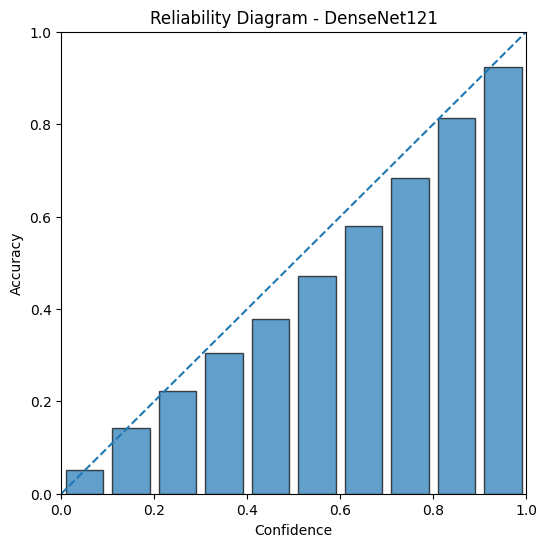

In [59]:
import numpy as np
import matplotlib.pyplot as plt

def compute_ece(y_true, y_prob, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1

    ece = 0.0
    bin_accs = []
    bin_confs = []
    bin_counts = []

    for b in range(n_bins):
        mask = bin_ids == b
        if np.sum(mask) > 0:
            acc = np.mean(y_true[mask])
            conf = np.mean(y_prob[mask])
            frac = np.mean(mask)

            ece += np.abs(acc - conf) * frac
            bin_accs.append(acc)
            bin_confs.append(conf)
            bin_counts.append(np.sum(mask))
        else:
            bin_accs.append(0.0)
            bin_confs.append(0.0)
            bin_counts.append(0)

    return ece, bins, np.array(bin_accs), np.array(bin_confs), np.array(bin_counts)

# Micro-average calibration across all labels
y_true_flat = val_labels.flatten()
y_prob_flat = val_probs.flatten()

ece, bins, bin_accs, bin_confs, bin_counts = compute_ece(y_true_flat, y_prob_flat, n_bins=10)

print(f"ECE: {ece:.4f}")

bin_centers = (bins[:-1] + bins[1:]) / 2

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle='--')
plt.bar(bin_centers, bin_accs, width=0.08, alpha=0.7, edgecolor='black')
plt.xlabel("Confidence")
plt.ylabel("Accuracy")
plt.title("Reliability Diagram - DenseNet121")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

### Now, we consider both frontal and lateral images

In [14]:
model_df = u_zeros_df.copy()

model_df["Study_ID"] = model_df["Path"].str.extract(r"(patient\d+/study\d+)")

print("Original rows:", model_df.shape[0])
print("Unique studies:", model_df["Study_ID"].nunique())
print(model_df["Frontal/Lateral"].value_counts(dropna=False))

Original rows: 219378
Unique studies: 183988
Frontal/Lateral
Frontal    187337
Lateral     32041
Name: count, dtype: int64


In [15]:
# We Split into frontal and lateral
frontal_df = model_df[model_df["Frontal/Lateral"] == "Frontal"].copy()
lateral_df = model_df[model_df["Frontal/Lateral"] == "Lateral"].copy()

# Keep only one image per study per view if duplicates exist
frontal_df = frontal_df.sort_values("Path").drop_duplicates(subset=["Study_ID"], keep="first")
lateral_df = lateral_df.sort_values("Path").drop_duplicates(subset=["Study_ID"], keep="first")

print("Frontal studies:", frontal_df["Study_ID"].nunique())
print("Lateral studies:", lateral_df["Study_ID"].nunique())

Frontal studies: 183972
Lateral studies: 31085


In [16]:
# Merge both Frontal and Lateral Images
study_df = frontal_df.merge(
    lateral_df[["Study_ID", "Path"]],
    on="Study_ID",
    how="inner",
    suffixes=("_frontal", "_lateral"))

# Keep labels and metadata from the frontal row and extract patient id again
study_df["Patient_ID"] = study_df["Study_ID"].str.extract(r"(patient\d+)")

print("Dual-view study dataset shape:", study_df.shape)
print("Unique patients:", study_df["Patient_ID"].nunique())
study_df[["Study_ID", "Path_frontal", "Path_lateral"]].head()

Dual-view study dataset shape: (31069, 21)
Unique patients: 22370


,Study_ID,Path_frontal,Path_lateral
0,patient00002/study1,CheXpert-v1.0/train/patient00002/study1/view1_...,CheXpert-v1.0/train/patient00002/study1/view2_...
1,patient00004/study1,CheXpert-v1.0/train/patient00004/study1/view1_...,CheXpert-v1.0/train/patient00004/study1/view2_...
2,patient00005/study1,CheXpert-v1.0/train/patient00005/study1/view1_...,CheXpert-v1.0/train/patient00005/study1/view2_...
3,patient00009/study1,CheXpert-v1.0/train/patient00009/study1/view1_...,CheXpert-v1.0/train/patient00009/study1/view2_...
4,patient00010/study1,CheXpert-v1.0/train/patient00010/study1/view1_...,CheXpert-v1.0/train/patient00010/study1/view2_...


## Splitting the dataset

In [17]:
from sklearn.model_selection import train_test_split

patient_ids = study_df["Patient_ID"].unique()

train_patients, val_patients = train_test_split(
    patient_ids,
    test_size=0.2,
    random_state=42
)

train_split_df = study_df[study_df["Patient_ID"].isin(train_patients)].copy()
val_split_df = study_df[study_df["Patient_ID"].isin(val_patients)].copy()

print("Train split shape:", train_split_df.shape)
print("Val split shape:", val_split_df.shape)

print("Train patients:", train_split_df["Patient_ID"].nunique())
print("Val patients:", val_split_df["Patient_ID"].nunique())

Train split shape: (24745, 21)
Val split shape: (6324, 21)
Train patients: 17896
Val patients: 4474


In [18]:
# Verify no patient overlap
train_patient_set = set(train_split_df["Patient_ID"].unique())
val_patient_set = set(val_split_df["Patient_ID"].unique())

overlap = train_patient_set.intersection(val_patient_set)
print("Number of overlapping patients:", len(overlap))

Number of overlapping patients: 0


In [19]:
# Check label prevalence
print("Train label prevalence:")
print(train_split_df[disease_cols].mean().sort_values(ascending=False))

print("\nValidation label prevalence:")
print(val_split_df[disease_cols].mean().sort_values(ascending=False))

Train label prevalence:
Lung Opacity                  0.327096
Pleural Effusion              0.295090
No Finding                    0.161245
Cardiomegaly                  0.129521
Atelectasis                   0.113397
Edema                         0.075975
Lung Lesion                   0.069590
Consolidation                 0.047969
Pneumothorax                  0.047727
Fracture                      0.047404
Enlarged Cardiomediastinum    0.035603
Pneumonia                     0.035482
Pleural Other                 0.035361
dtype: float64

Validation label prevalence:
Lung Opacity                  0.323055
Pleural Effusion              0.287634
No Finding                    0.159709
Cardiomegaly                  0.130455
Atelectasis                   0.116856
Edema                         0.078748
Lung Lesion                   0.062935
Pneumothorax                  0.050917
Fracture                      0.044750
Consolidation                 0.038109
Pleural Other                 0.03

## Image Preprocessing 2

## Model 3: CamChex

In [37]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, BatchSampler
from torchvision import models, transforms
from torch.cuda.amp import GradScaler, autocast
from PIL import Image
from tqdm import tqdm

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
torch.backends.cudnn.benchmark = True
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# ── Path resolution ───────────────────────────────────────────────────────────
BASE = "/home/ubuntu/chexpert/chexpertchestxrays-u20210408"
BATCH_DIRS = [
    f"{BASE}/CheXpert-v1.0 batch 2 (train 1)",
    f"{BASE}/CheXpert-v1.0 batch 3 (train 2)",
    f"{BASE}/CheXpert-v1.0 batch 4 (train 3)",
]

def resolve_path(csv_path):
    relative = csv_path.replace("CheXpert-v1.0/train/", "")
    for batch_dir in BATCH_DIRS:
        candidate = os.path.join(batch_dir, relative)
        if os.path.exists(candidate):
            return candidate
    return None

Using device: cuda


In [38]:
# ── Transforms ────────────────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [39]:
# ── Dataset ───────────────────────────────────────────────────────────────────
class CheXpertDualViewDataset(Dataset):
    def __init__(self, df, label_cols, transform=None):
        self.df = df.reset_index(drop=True)
        self.label_cols = label_cols
        self.transform = transform
        print(f"Dataset size: {len(self.df)} studies")

    def __len__(self):
        return len(self.df)

    def _load_image(self, path):
        img_path = resolve_path(path)
        try:
            image = Image.open(img_path).convert("RGB")
        except (FileNotFoundError, OSError, TypeError):
            image = Image.new("RGB", (224, 224), 0)
        if self.transform:
            image = self.transform(image)
        return image

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        frontal_img = self._load_image(row["Path_frontal"])
        lateral_img = self._load_image(row["Path_lateral"])
        labels = row[self.label_cols].values.astype(np.float32)
        return frontal_img, lateral_img, torch.tensor(labels, dtype=torch.float32)

In [40]:
# ── Balanced Batch Sampler ────────────────────────────────────────────────────
class MultilabelBalancedBatchSampler(BatchSampler):
    """
    Builds batches with:
    - half positive studies (at least one disease present)
    - half negative studies (all disease labels are 0)
    Inside the positive pool, rarer-class samples are favored using
    a rarity score based on inverse class frequency.
    """
    def __init__(self, labels_df, batch_size, pos_fraction=0.5):
        self.labels = labels_df.values.astype(np.float32)
        self.batch_size = batch_size
        self.num_pos = max(1, int(batch_size * pos_fraction))
        self.num_neg = batch_size - self.num_pos

        self.positive_mask = (self.labels.sum(axis=1) > 0)
        self.negative_mask = ~self.positive_mask
        self.positive_indices = np.where(self.positive_mask)[0]
        self.negative_indices = np.where(self.negative_mask)[0]

        if len(self.positive_indices) == 0:
            raise ValueError("No positive samples found.")
        if len(self.negative_indices) == 0:
            raise ValueError("No negative samples found.")

        class_counts = self.labels.sum(axis=0)
        class_inv_freq = 1.0 / (class_counts + 1e-6)
        sample_scores = (self.labels * class_inv_freq).sum(axis=1)
        pos_scores = np.clip(sample_scores[self.positive_indices], 1e-8, None)
        self.pos_prob = pos_scores / pos_scores.sum()
        self.n_batches = len(labels_df) // batch_size

    def __iter__(self):
        for _ in range(self.n_batches):
            pos_batch = np.random.choice(
                self.positive_indices, size=self.num_pos,
                replace=True, p=self.pos_prob
            )
            neg_batch = np.random.choice(
                self.negative_indices, size=self.num_neg,
                replace=True
            )
            batch = np.concatenate([pos_batch, neg_batch])
            np.random.shuffle(batch)
            yield batch.tolist()

    def __len__(self):
        return self.n_batches

In [41]:
# ── Model ─────────────────────────────────────────────────────────────────────
class CaMCheXDualView(nn.Module):
    """
    Dual-view CheXpert model.

    Memory options (set at init):
      shared_weights=True  → one backbone, run twice  (~halves param memory)
      use_checkpointing=True → gradient checkpointing (~halves activation memory)
    """
    def __init__(self, num_classes, shared_weights=True, use_checkpointing=True):
        super().__init__()
        self.use_checkpointing = use_checkpointing

        backbone = models.convnext_tiny(
            weights=models.ConvNeXt_Tiny_Weights.DEFAULT
        )
        in_features = backbone.classifier[2].in_features
        backbone.classifier = nn.Identity()

        if shared_weights:
            # One backbone, called twice — halves parameter memory
            self.frontal_encoder = backbone
            self.lateral_encoder = backbone
        else:
            # Two independent backbones
            import copy
            self.frontal_encoder = backbone
            self.lateral_encoder = copy.deepcopy(backbone)

        self.classifier = nn.Sequential(
            nn.Linear(in_features * 2, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def _encode(self, encoder, x):
        if self.use_checkpointing and self.training:
            return torch.utils.checkpoint.checkpoint(
                encoder, x, use_reentrant=False
            )
        return encoder(x)

    def forward(self, frontal_img, lateral_img):
        frontal_feat = torch.flatten(self._encode(self.frontal_encoder, frontal_img), 1)
        lateral_feat = torch.flatten(self._encode(self.lateral_encoder, lateral_img), 1)
        return self.classifier(torch.cat([frontal_feat, lateral_feat], dim=1))

In [42]:
# ── Datasets & Loaders ────────────────────────────────────────────────────────
BATCH_SIZE = 32

print("Building train dataset...")
train_dataset = CheXpertDualViewDataset(
    df=train_split_df,
    label_cols=disease_cols,
    transform=train_transform
)

print("Building val dataset...")
val_dataset = CheXpertDualViewDataset(
    df=val_split_df,
    label_cols=disease_cols,
    transform=val_transform
)

balanced_batch_sampler = MultilabelBalancedBatchSampler(
    labels_df=train_dataset.df[disease_cols],
    batch_size=BATCH_SIZE
)

train_loader = DataLoader(
    train_dataset,
    batch_sampler=balanced_batch_sampler,
    num_workers=8,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=8,
    pin_memory=True,
    persistent_workers=True
)


Building train dataset...
Dataset size: 24745 studies
Building val dataset...
Dataset size: 6324 studies


In [43]:
# ── Model / Optimizer / Loss ──────────────────────────────────────────────────
camchex = CaMCheXDualView(
    num_classes=len(disease_cols),
    shared_weights=True,       # ← set False to restore independent backbones
    use_checkpointing=True     # ← trades compute for activation memory
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(camchex.parameters(), lr=1e-4, weight_decay=1e-2)
scaler    = GradScaler()   # mixed precision — fp16 forward, fp32 gradients

# Sanity check
with torch.no_grad():
    f = torch.randn(2, 3, 224, 224).to(device)
    l = torch.randn(2, 3, 224, 224).to(device)
    print(f"Model output shape: {camchex(f, l).shape}")
    del f, l
torch.cuda.empty_cache()

/tmp/ipykernel_2853/2881516902.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()   # mixed precision — fp16 forward, fp32 gradients


Model output shape: torch.Size([2, 13])


In [42]:
# ── Train / Val Functions ─────────────────────────────────────────────────────
def train_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    running_loss = 0.0
    for frontal_imgs, lateral_imgs, labels in tqdm(loader, desc="Training", leave=False):
        frontal_imgs = frontal_imgs.to(device, non_blocking=True)
        lateral_imgs = lateral_imgs.to(device, non_blocking=True)
        labels       = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        with autocast():                                      # fp16 forward pass
            loss = criterion(model(frontal_imgs, lateral_imgs), labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * labels.size(0)
    return running_loss / len(loader.dataset)

def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_labels, all_probs = [], []
    with torch.no_grad():
        for frontal_imgs, lateral_imgs, labels in tqdm(loader, desc="Validation", leave=False):
            frontal_imgs = frontal_imgs.to(device, non_blocking=True)
            lateral_imgs = lateral_imgs.to(device, non_blocking=True)
            labels       = labels.to(device, non_blocking=True)
            with autocast():
                outputs = model(frontal_imgs, lateral_imgs)
            running_loss += criterion(outputs, labels).item() * labels.size(0)
            all_labels.append(labels.cpu())
            all_probs.append(torch.sigmoid(outputs).cpu())
    return (
        running_loss / len(loader.dataset),
        torch.cat(all_labels),
        torch.cat(all_probs)
    )

# ── Training Run ──────────────────────────────────────────────────────────────
num_epochs      = 5
best_val_loss   = float("inf")
best_model_path = "best_camchex_uzeros.pth"

for epoch in tqdm(range(num_epochs), desc="Epochs"):
    torch.cuda.empty_cache()   # clear fragmentation between epochs

    train_loss = train_epoch(
        camchex, train_loader, criterion, optimizer, scaler, device
    )
    val_loss, val_labels, val_probs = validate_epoch(
        camchex, val_loader, criterion, device
    )

    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print(f"  Train Loss : {train_loss:.4f}")
    print(f"  Val Loss   : {val_loss:.4f}")
    print("-" * 30)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(camchex.state_dict(), best_model_path)
        print(f"  Best model saved → {best_model_path}")

Using device: cuda
Building train dataset...
Dataset size: 24745 studies
Building val dataset...
Dataset size: 6324 studies


/tmp/ipykernel_2378/1683715905.py:227: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()   # mixed precision — fp16 forward, fp32 gradients


Model output shape: torch.Size([2, 13])


Training:   0%|          | 0/773 [00:00<?, ?it/s]/tmp/ipykernel_2378/1683715905.py:247: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():                                      # fp16 forward pass

Training: 100%|██████████| 773/773 [04:14<00:00,  3.39it/s]
                                                           
Validation:   0%|          | 0/198 [00:00<?, ?it/s]/tmp/ipykernel_2378/1683715905.py:265: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():

Validation: 100%|██████████| 198/198 [01:45<00:00,  1.61it/s]
                                                             


Epoch [1/5]
  Train Loss : 0.2458
  Val Loss   : 0.2708
------------------------------


...

  Best model saved → best_camchex_uzeros.pth



Training: 100%|██████████| 773/773 [04:12<00:00,  2.56it/s]
                                                           
Epochs:  80%|████████  | 4/5 [24:03<05:59, 359.79s/it]       


Epoch [4/5]
  Train Loss : 0.1966
  Val Loss   : 0.2603
------------------------------



Training: 100%|██████████| 773/773 [04:08<00:00,  3.61it/s]
                                                           
Epochs: 100%|██████████| 5/5 [30:13<00:00, 362.67s/it]       


Epoch [5/5]
  Train Loss : 0.1846
  Val Loss   : 0.2641
------------------------------


In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np

# Load best model before evaluation
camchex.load_state_dict(torch.load(best_model_path, map_location=device))
camchex = camchex.to(device)

val_loss, val_labels, val_probs = validate_epoch(
    camchex, val_loader, criterion, device
)

if isinstance(val_probs, torch.Tensor):
    val_probs = val_probs.cpu().numpy()

if isinstance(val_labels, torch.Tensor):
    val_labels = val_labels.cpu().numpy()

val_preds = (val_probs >= 0.5).astype(int)

results = []
aurocs = []

for i, disease in enumerate(disease_cols):

    y_true = val_labels[:, i]
    y_pred = val_preds[:, i]
    y_prob = val_probs[:, i]

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    try:
        auroc = roc_auc_score(y_true, y_prob)
        aurocs.append(auroc)
    except:
        auroc = np.nan

    results.append({
        "Disease": disease,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "AUROC": auroc
    })

metrics_df = pd.DataFrame(results)

macro_auroc = np.nanmean(aurocs)

try:
    micro_auroc = roc_auc_score(val_labels.flatten(), val_probs.flatten())
except:
    micro_auroc = np.nan

print("\n=========================")
print(f"Overall Macro AUROC : {macro_auroc:.4f}")
print(f"Overall Micro AUROC : {micro_auroc:.4f}")
print("=========================\n")

metrics_df

Validation:   0%|          | 0/198 [00:00<?, ?it/s]/tmp/ipykernel_2378/1683715905.py:265: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
                                                             


Overall Macro AUROC : 0.7643
Overall Micro AUROC : 0.8307



,Disease,Accuracy,Precision,Recall,F1 Score,AUROC
0,No Finding,0.840291,0.000000,0.000000,0.000000,0.855861
1,Enlarged Cardiomediastinum,0.964421,0.000000,0.000000,0.000000,0.603314
2,Cardiomegaly,0.890892,0.623400,0.413333,0.497085,0.867112
3,Lung Opacity,0.712524,0.619554,0.285365,0.390751,0.733349
4,Lung Lesion,0.937065,0.000000,0.000000,0.000000,0.684510
5,Edema,0.918722,0.482301,0.437751,0.458947,0.872970
6,Consolidation,0.960152,0.210526,0.016598,0.030769,0.777608
7,Pneumonia,0.967268,0.375000,0.092308,0.148148,0.763540
8,Atelectasis,0.882669,0.333333,0.004060,0.008021,0.715756
9,Pneumothorax,0.950190,0.530973,0.186335,0.275862,0.865384


ECE: 0.0131


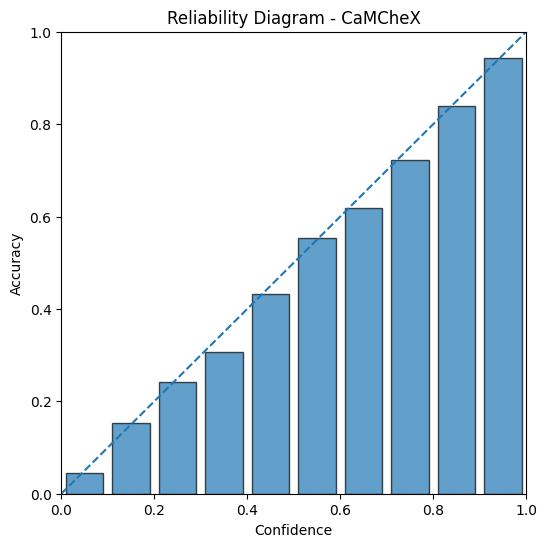

In [44]:
import numpy as np
import matplotlib.pyplot as plt

def compute_ece(y_true, y_prob, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)

    ece = 0.0
    bin_accs = []
    bin_confs = []
    bin_counts = []

    for b in range(n_bins):
        mask = bin_ids == b
        if np.sum(mask) > 0:
            acc = np.mean(y_true[mask])
            conf = np.mean(y_prob[mask])
            frac = np.mean(mask)

            ece += np.abs(acc - conf) * frac
            bin_accs.append(acc)
            bin_confs.append(conf)
            bin_counts.append(np.sum(mask))
        else:
            bin_accs.append(0.0)
            bin_confs.append(0.0)
            bin_counts.append(0)

    return ece, bins, np.array(bin_accs), np.array(bin_confs), np.array(bin_counts)

# Micro-average calibration across all labels
y_true_flat = val_labels.flatten()
y_prob_flat = val_probs.flatten()

ece, bins, bin_accs, bin_confs, bin_counts = compute_ece(y_true_flat, y_prob_flat, n_bins=10)

print(f"ECE: {ece:.4f}")

bin_centers = (bins[:-1] + bins[1:]) / 2

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle='--')
plt.bar(bin_centers, bin_accs, width=0.08, alpha=0.7, edgecolor='black')
plt.xlabel("Confidence")
plt.ylabel("Accuracy")
plt.title("Reliability Diagram - CaMCheX")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

## Model 4: Multiview Dual Branch Network

In [44]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
torch.backends.cudnn.benchmark = True
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

class MultiViewDualBranchNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # Frontal branch
        frontal_backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        frontal_in_features = frontal_backbone.fc.in_features
        frontal_backbone.fc = nn.Identity()

        # Lateral branch
        lateral_backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        lateral_in_features = lateral_backbone.fc.in_features
        lateral_backbone.fc = nn.Identity()

        self.frontal_branch = frontal_backbone
        self.lateral_branch = lateral_backbone

        fusion_dim = frontal_in_features + lateral_in_features

        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, frontal_img, lateral_img):
        frontal_feat = self.frontal_branch(frontal_img)
        lateral_feat = self.lateral_branch(lateral_img)

        fused = torch.cat((frontal_feat, lateral_feat), dim=1)
        out = self.classifier(fused)

        return out

multiview_dual_branch = MultiViewDualBranchNet(num_classes=len(disease_cols)).to(device)

print(multiview_dual_branch)

Using device: cuda
MultiViewDualBranchNet(
  (frontal_branch): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e

In [45]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(multiview_dual_branch.parameters(), lr=1e-4)

In [46]:
from tqdm import tqdm

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for frontal_imgs, lateral_imgs, labels in progress_bar:
        frontal_imgs = frontal_imgs.to(device, non_blocking=True)
        lateral_imgs = lateral_imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(frontal_imgs, lateral_imgs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        progress_bar.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss

In [47]:
def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    all_labels = []
    all_probs = []

    with torch.no_grad():
        progress_bar = tqdm(loader, desc="Validation", leave=False)

        for frontal_imgs, lateral_imgs, labels in progress_bar:
            frontal_imgs = frontal_imgs.to(device, non_blocking=True)
            lateral_imgs = lateral_imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(frontal_imgs, lateral_imgs)
            loss = criterion(outputs, labels)

            probs = torch.sigmoid(outputs)

            running_loss += loss.item() * labels.size(0)

            all_labels.append(labels.cpu())
            all_probs.append(probs.cpu())

    epoch_loss = running_loss / len(loader.dataset)
    all_labels = torch.cat(all_labels, dim=0)
    all_probs = torch.cat(all_probs, dim=0)

    return epoch_loss, all_labels, all_probs

In [51]:
num_epochs = 7
best_val_loss = float("inf")
best_model_path = "best_multiview_dual_branch_uzeros.pth"

for epoch in tqdm(range(num_epochs), desc="Epochs"):

    train_loss = train_epoch(multiview_dual_branch, train_loader, criterion, optimizer, device)

    val_loss, val_labels, val_probs = validate_epoch(
        multiview_dual_branch, val_loader, criterion, device
    )

    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    print("-" * 30)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(multiview_dual_branch.state_dict(), best_model_path)
        print(f"Best model saved to {best_model_path}")

Training: 100%|█████████▉| 772/773 [04:06<00:00,  2.08it/s, loss=0.195]
                                                                       
Epochs:  14%|█▍        | 1/7 [05:35<33:32, 335.47s/it]       


Epoch [1/7]
Train Loss: 0.2061
Val Loss:   0.2741
------------------------------
Best model saved to best_multiview_dual_branch_uzeros.pth



Training: 100%|█████████▉| 772/773 [04:01<00:00,  3.25it/s, loss=0.185]
                                                                       
Validation:  98%|█████████▊| 194/198 [01:59<00:02,  1.47it/s]
                                                             


Epoch [2/7]
Train Loss: 0.1975
Val Loss:   0.2669
------------------------------


Epochs:  29%|██▊       | 2/7 [11:36<29:11, 350.32s/it]

...


Epoch [5/7]
Train Loss: 0.1742
Val Loss:   0.2821
------------------------------



Training: 100%|██████████| 773/773 [04:01<00:00,  3.22it/s, loss=0.14]
                                                                      
Epochs:  86%|████████▌ | 6/7 [35:33<05:59, 359.23s/it]       


Epoch [6/7]
Train Loss: 0.1657
Val Loss:   0.2893
------------------------------



Training: 100%|█████████▉| 772/773 [04:03<00:00,  3.88it/s, loss=0.153]
                                                                       
Epochs: 100%|██████████| 7/7 [41:15<00:00, 353.69s/it]       


Epoch [7/7]
Train Loss: 0.1565
Val Loss:   0.2993
------------------------------


In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np

# Load best model before evaluation
multiview_dual_branch.load_state_dict(torch.load(best_model_path, map_location=device))
multiview_dual_branch = multiview_dual_branch.to(device)

val_loss, val_labels, val_probs = validate_epoch(
    multiview_dual_branch, val_loader, criterion, device
)

if isinstance(val_probs, torch.Tensor):
    val_probs = val_probs.cpu().numpy()

if isinstance(val_labels, torch.Tensor):
    val_labels = val_labels.cpu().numpy()

val_preds = (val_probs >= 0.5).astype(int)

results = []
aurocs = []

for i, disease in enumerate(disease_cols):

    y_true = val_labels[:, i]
    y_pred = val_preds[:, i]
    y_prob = val_probs[:, i]

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    try:
        auroc = roc_auc_score(y_true, y_prob)
        aurocs.append(auroc)
    except:
        auroc = np.nan

    results.append({
        "Disease": disease,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "AUROC": auroc
    })

metrics_df = pd.DataFrame(results)

macro_auroc = np.nanmean(aurocs)

try:
    micro_auroc = roc_auc_score(val_labels.flatten(), val_probs.flatten())
except:
    micro_auroc = np.nan

print("\n=========================")
print(f"Overall Macro AUROC : {macro_auroc:.4f}")
print(f"Overall Micro AUROC : {micro_auroc:.4f}")
print("=========================\n")

metrics_df


Overall Macro AUROC : 0.7583
Overall Micro AUROC : 0.8287



,Disease,Accuracy,Precision,Recall,F1 Score,AUROC
0,No Finding,0.840291,0.000000,0.000000,0.000000,0.845762
1,Enlarged Cardiomediastinum,0.964421,0.000000,0.000000,0.000000,0.615898
2,Cardiomegaly,0.877451,0.541528,0.395152,0.456903,0.842725
3,Lung Opacity,0.700822,0.635548,0.173275,0.272308,0.718895
4,Lung Lesion,0.937065,0.500000,0.005025,0.009950,0.681012
5,Edema,0.913030,0.450570,0.475904,0.462891,0.863520
6,Consolidation,0.957938,0.162162,0.024896,0.043165,0.770115
7,Pneumonia,0.965686,0.176471,0.030769,0.052402,0.750719
8,Atelectasis,0.871917,0.351464,0.113667,0.171779,0.722213
9,Pneumothorax,0.945604,0.390000,0.121118,0.184834,0.840593


ECE: 0.0239


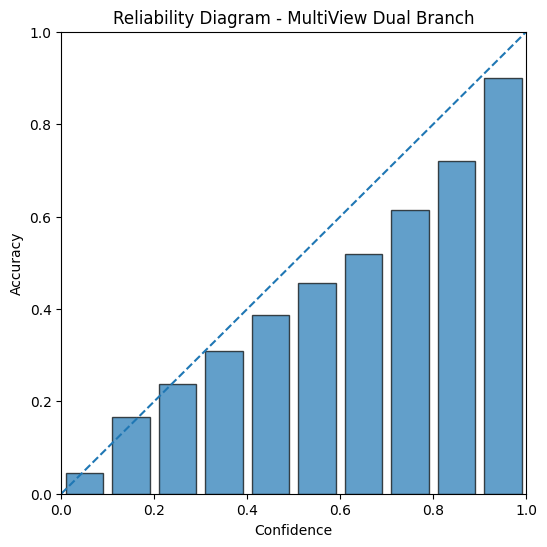

In [53]:
import numpy as np
import matplotlib.pyplot as plt

def compute_ece(y_true, y_prob, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)

    ece = 0.0
    bin_accs = []
    bin_confs = []
    bin_counts = []

    for b in range(n_bins):
        mask = bin_ids == b
        if np.sum(mask) > 0:
            acc = np.mean(y_true[mask])
            conf = np.mean(y_prob[mask])
            frac = np.mean(mask)

            ece += np.abs(acc - conf) * frac
            bin_accs.append(acc)
            bin_confs.append(conf)
            bin_counts.append(np.sum(mask))
        else:
            bin_accs.append(0.0)
            bin_confs.append(0.0)
            bin_counts.append(0)

    return ece, bins, np.array(bin_accs), np.array(bin_confs), np.array(bin_counts)

# Micro-average calibration across all labels
y_true_flat = val_labels.flatten()
y_prob_flat = val_probs.flatten()

ece, bins, bin_accs, bin_confs, bin_counts = compute_ece(y_true_flat, y_prob_flat, n_bins=10)

print(f"ECE: {ece:.4f}")

bin_centers = (bins[:-1] + bins[1:]) / 2

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle='--')
plt.bar(bin_centers, bin_accs, width=0.08, alpha=0.7, edgecolor='black')
plt.xlabel("Confidence")
plt.ylabel("Accuracy")
plt.title("Reliability Diagram - MultiView Dual Branch")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()


# Handling Uncertianty in Models: DenseNet 

##  1. Monte carlo Dropout

In [40]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

densenet121 = models.densenet121(weights=None)
in_features = densenet121.classifier.in_features
densenet121.classifier = nn.Linear(in_features, len(disease_cols))
densenet121 = densenet121.to(device)

state_dict = torch.load('best_densenet121_uzeros.pth', weights_only=False)
densenet121.load_state_dict(state_dict)
densenet121.eval()
print("Model loaded successfully!")

Model loaded successfully!


In [41]:
class DenseNetWithMCDropout(nn.Module):
    def __init__(self, base_model, num_classes, dropout_rate=0.3):
        super().__init__()
        self.features = base_model.features
        self.dropout = nn.Dropout(p=dropout_rate)
        self.classifier = base_model.classifier

    def forward(self, x):
        features = self.features(x)
        out = torch.relu(features)
        out = torch.nn.functional.adaptive_avg_pool2d(out, (1, 1))
        out = torch.flatten(out, 1)
        out = self.dropout(out)
        out = self.classifier(out)
        return out

mc_model = DenseNetWithMCDropout(densenet121, num_classes=len(disease_cols), dropout_rate=0.3)
mc_model = mc_model.to(device)
print("MC Dropout model ready")

for name, module in mc_model.named_modules():
    if isinstance(module, nn.Dropout):
        print(f"Dropout found: {name}, p={module.p}")

MC Dropout model ready
Dropout found: dropout, p=0.3


In [42]:
import numpy as np
from tqdm import tqdm

def enable_mc_dropout(model):
    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.train()
            print(f"Dropout enabled: p={module.p}")

def mc_dropout_predict(model, loader, device, n_passes=30):
    model.eval()
    enable_mc_dropout(model)  # turn dropout back on after eval

    all_means, all_vars, all_labels = [], [], []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="MC Dropout"):
            images = images.to(device)
            batch_preds = []
            for _ in range(n_passes):
                outputs = model(images)
                probs = torch.sigmoid(outputs)
                batch_preds.append(probs.cpu())

            batch_preds = torch.stack(batch_preds, dim=0)
            all_means.append(batch_preds.mean(dim=0))
            all_vars.append(batch_preds.var(dim=0))
            all_labels.append(labels)

    return (
        torch.cat(all_means,  dim=0).numpy(),
        torch.cat(all_vars,   dim=0).numpy(),
        torch.cat(all_labels, dim=0).numpy()
    )

## 2. Shanon Entropy

In [43]:
def shannon_entropy(probs, epsilon=1e-10):
    entropy = -(
        probs * np.log(probs + epsilon) +
        (1 - probs) * np.log(1 - probs + epsilon)
    )
    return entropy.mean(axis=1)

In [44]:
print("Running Monte Carlo Dropout (30 passes)...")
mc_means, mc_vars, mc_labels = mc_dropout_predict(
    mc_model, val_loader, device, n_passes=30  # mc_model not densenet121
)

entropy_scores = shannon_entropy(mc_means)

print(f"\nMean epistemic uncertainty (variance) : {mc_vars.mean():.6f}")
print(f"Mean Shannon entropy                  : {entropy_scores.mean():.4f}")
print(f"Most uncertain sample                 : {entropy_scores.max():.4f}")
print(f"Most certain sample                   : {entropy_scores.min():.4f}")

Running Monte Carlo Dropout (30 passes)...
Dropout enabled: p=0.3


MC Dropout: 100%|██████████| 287/287 [35:24<00:00,  7.40s/it]


Mean epistemic uncertainty (variance) : 0.001595
Mean Shannon entropy                  : 0.2547
Most uncertain sample                 : 0.4789
Most certain sample                   : 0.0157


In [45]:
import pandas as pd

per_disease_variance = mc_vars.mean(axis=0)
per_disease_entropy  = (-(
    mc_means * np.log(mc_means + 1e-10) +
    (1 - mc_means) * np.log(1 - mc_means + 1e-10)
)).mean(axis=0)

uncertainty_df = pd.DataFrame({
    'Disease': disease_cols,
    'Epistemic Uncertainty (Variance)': per_disease_variance,
    'Aleatoric Uncertainty (Entropy)':  per_disease_entropy
}).sort_values('Epistemic Uncertainty (Variance)', ascending=False).reset_index(drop=True)

print("Per-disease uncertainty breakdown:")
display(uncertainty_df)

Per-disease uncertainty breakdown:


,Disease,Epistemic Uncertainty (Variance),Aleatoric Uncertainty (Entropy)
0,Lung Opacity,0.004058,0.499877
1,Edema,0.002945,0.385262
2,Pleural Effusion,0.002846,0.348765
3,Atelectasis,0.002210,0.374079
4,Consolidation,0.001836,0.299470
5,Cardiomegaly,0.001815,0.274696
6,Pneumonia,0.001238,0.193084
7,Pneumothorax,0.001033,0.183213
8,Lung Lesion,0.000790,0.180854
9,Enlarged Cardiomediastinum,0.000749,0.197725


In [46]:
np.save('mc_means.npy',       mc_means)
np.save('mc_vars.npy',        mc_vars)
np.save('mc_labels.npy',      mc_labels)
np.save('entropy_scores.npy', entropy_scores)
uncertainty_df.to_csv('uncertainty_per_disease.csv', index=False)
print("All outputs saved.")

All outputs saved.
